In [1]:
%load_ext autoreload

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib import container
import numpy as np
import os
import pandas as pd
from pathlib import Path
from scipy import stats
import seaborn as sns
import statsmodels.api as sm
import tabulate 

import IPython

In [3]:
%autoreload 2

from util import *

In [4]:
sns.set_theme(style="whitegrid", font_scale=1.1)

# Load Data

In [5]:
# CPI: https://www.minneapolisfed.org/about-us/monetary-policy/inflation-calculator/consumer-price-index-1913-
cpi_map = {
    2013: 233,
    2014: 236.7,
    2015: 237,
    2016: 240,
    2017: 245.1,
    2018: 251.1,
    2019: 255.7,
    2020: 258.8,
    2021: 271,
    2022: 292.7,
    2023: 304.7,
    2024: 313.7,
    2025: 322.3
}

In [6]:
final_spine_codes = [
    '22551', '22552', '22548', '63081', '63082', '22554', '22585', '22856', '22845', '22846', '22558', '22585', 
    '22630', '22632', '22600', '22590', '22595', '22614', '22840', '22612', '22842', '22843', '63020', '63035', 
    '63040', '63045', '63048', '63051', '63077', '23078', '23085', '63086', '63087', '63088', '63101', '63103', 
    '22556', '22585', '22851', '22845', '22846', '63046', '63048', '63055', '63057', '63064', '63066', '63085', 
    '63086', '63087', '22610', '66214', '22840', '22842', '22843', '22844', '63090', '63091', '22558', '22585', 
    '22857', '22862', '22845', '22846', '63030', '63047', '63035', '63042', '63044', '63048', '63012', '22630', 
    '22632', '22612', '22614', '22633', '22634', '22840', '22842', '22843', '22853', "22854", "22859", '22847',
    "63001", "63015", "63043", "63050", "63075", "63076", "63003", "63016", "63005", "63017", "63052", "63053",
    "62380", "22800", "22802", "22804", "22810", "22812", "22534", "22532", "22533"
]

final_neurovasc_codes = ["61624", "61626", "61645", "61635", "37215", "37216", "37236", "37237"]

# other codes
# 22849 - reinsertion due to device failure
# 75898 - diagnostic for neuroIR?

In [7]:
spine_addons = [
    "22552", "63082", "22585", "22585", "22632", "22614", "63048", "23078", "63086", "63088", "63103", "22585",
    "63048", "63066", "63086", "63091", "22585", "63044", "63048", "22632", "22614", "22634", "63035", "63043",
    "63053", "63057", "63076", "63076", "22534"
]

# spine_addons_old = [
#     "63035", "63043", "63044", "63048", "63053", "22552", "22632", "22634", "22614",
#     "63057", "63066", "63076", "63082", "63086", "63088", "63091", "63103",
# ]

neurovasc_addons = ['37237', '61642']

In [8]:
cpt_spine = {
    "instrumentation": [
        "22840", "22842", "22843", "22844", "22845", "22846", "22847", "22853", 
        "22854", "22859", "22849"
    ],
    "bone_grafting": [
        "20930", "20931", "20936", "20937", "20938", "20939"
    ],
    "decompression": [
        "63001", "63015", "63045", "63020", "63040", "63043", "63048", "63035", 
        "63050", "63051", "63075", "63076", "63081", "63082", "63003", "63016",
        "63046", "63085", "63086", "63087", "63005", "63017", "63047", "63030",
        "63042", "63044", "63052", "63053", "62380", "63090", "63091", "63012",
        "63055", "63057", "63064", "63066", "63077", "63088", "63101", "63103"
    ],
    "fusion": [
        "22800", "22802", "22804", "22810", "22812", "22585", "22614", "22534", 
        "22551", "22552", "22554", "22590", "22595", "22556", "22532", "22558",
        "22533", "22612", "22630", "22632", "22633", "22634", "22548", "22600",
        "22610", "23078", "23085"
    ],
}   

cpt_neurovasc = {
    'aneurysm_embo': ['61624', '61626'],
    'transcath_therapy': ['75894'],
    'thrombectomy': ['61645'],
    'stent': ['37215', '37216', '37236', '37237'],
    'intracranial_angioplasty': ['61635', '61630', '61640', '61641', '61642']
}

In [9]:
for name in cpt_spine:
    print(name)
    print(", ".join([code for code in cpt_spine[name] if code not in spine_addons]))

instrumentation
22840, 22842, 22843, 22844, 22845, 22846, 22847, 22853, 22854, 22859, 22849
bone_grafting
20930, 20931, 20936, 20937, 20938, 20939
decompression
63001, 63015, 63045, 63020, 63040, 63050, 63051, 63075, 63081, 63003, 63016, 63046, 63085, 63087, 63005, 63017, 63047, 63030, 63042, 63052, 62380, 63090, 63012, 63055, 63064, 63077, 63101
fusion
22800, 22802, 22804, 22810, 22812, 22551, 22554, 22590, 22595, 22556, 22532, 22558, 22533, 22612, 22630, 22633, 22548, 22600, 22610, 23085


In [10]:
for name in cpt_neurovasc:
    print(name)
    print(", ".join([code for code in cpt_neurovasc[name] if code not in neurovasc_addons]))

aneurysm_embo
61624, 61626
transcath_therapy
75894
thrombectomy
61645
stent
37215, 37216, 37236
intracranial_angioplasty
61635, 61630, 61640, 61641


In [11]:
cpt_map = {}

for category, codes in cpt_spine.items():
    for code in codes:
        if code not in spine_addons:
            cpt_map[int(code)] = category

for category, codes in cpt_neurovasc.items():
    for code in codes:
        if code not in neurovasc_addons:
            cpt_map[int(code)] = category

In [12]:
current_dir = os.getcwd()

In [13]:
spine_data = pd.read_csv(os.path.join(current_dir, "processed-data", "spine_cpt_processed.csv"))
neurovasc_data = pd.read_csv(os.path.join(current_dir, "processed-data", "neurovasc_cpt_processed.csv"))

# Set Up Dataframes

In [14]:
for df in [spine_data, neurovasc_data]:
    df['CPI'] = df['year'].map(cpi_map).fillna(0)
    
    # Adjusted amounts
    df['Avg_Mdcr_Stdzd_Amt_adj'] = df['Avg_Mdcr_Stdzd_Amt'] / df['CPI'] * cpi_map[2023]
    df['Avg_Mdcr_Pymt_Amt_adj'] = df['Avg_Mdcr_Pymt_Amt'] / df['CPI'] * cpi_map[2023]

    # Raw amounts summed over services per provider
    df['Tot_Srvcs_Spend'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Stdzd_Amt'] 
    df['Tot_Pymt'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Pymt_Amt'] 

    # Raw amounts summed over services per provider, adjusted
    df['Tot_Srvcs_Spend_adj'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Stdzd_Amt_adj'] 
    df['Tot_Pymt_adj'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Pymt_Amt_adj'] 

# Select only necessary comlumns
spine_data = spine_data[[
    "HCPCS_Cd", "Rndrng_NPI", "Tot_Srvcs", "Avg_Mdcr_Stdzd_Amt", "Avg_Mdcr_Pymt_Amt", 
    "Tot_Srvcs_Spend", "Tot_Pymt", "Avg_Mdcr_Stdzd_Amt_adj", "Avg_Mdcr_Pymt_Amt_adj",
    "Tot_Srvcs_Spend_adj", "Tot_Pymt_adj", "year"
]]
neurovasc_data = neurovasc_data[[
    "HCPCS_Cd", "Rndrng_NPI", "Tot_Srvcs", "Avg_Mdcr_Stdzd_Amt", "Avg_Mdcr_Pymt_Amt", 
    "Tot_Srvcs_Spend", "Tot_Pymt", "Avg_Mdcr_Stdzd_Amt_adj", "Avg_Mdcr_Pymt_Amt_adj",
    "Tot_Srvcs_Spend_adj", "Tot_Pymt_adj", "year"
]]

for data in [spine_data, neurovasc_data]:
    data['procedure'] = data['HCPCS_Cd'].map(cpt_map)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_25470/3249098086.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['procedure'] = data['HCPCS_Cd'].map(cpt_map)


In [15]:
groupby_key = 'procedure'
specialty_name = ["Spine", "Neurovascular"]

# Group by procedure and year, and summarize
util_2023_2013_adj_spine = (
    spine_data
    .groupby([groupby_key, 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique())
    )
)

util_2023_2013_adj_neurovasc = (
    neurovasc_data
    .groupby([groupby_key, 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique()))
)

# Get CIs for Avg_Mdcr_Stdzd_Amt
ci_spine = bootstrap_agg_price_ci(spine_data, groupby_key)
util_2023_2013_adj_spine = util_2023_2013_adj_spine.merge(ci_spine, on=[groupby_key, 'year'], how='left')

ci_neurovasc = bootstrap_agg_price_ci(neurovasc_data, groupby_key)
util_2023_2013_adj_neurovasc = util_2023_2013_adj_neurovasc.merge(ci_neurovasc, on=[groupby_key, 'year'], how='left')

In [16]:
for df in [util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]:
    df['Agg_Price_per_service_adj'] = df['Sum_Spend_adj'] / df['Sum_Utilization']

In [17]:
# util_2023_2013_adj_spine = util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'] >= 2016].reset_index(drop=True)
# util_2023_2013_adj_neurovasc = util_2023_2013_adj_neurovasc[util_2023_2013_adj_neurovasc['year'] >= 2016].reset_index(drop=True)

# Utilization

In [18]:
util_2023_2013_adj_spine['Sum_Utilization'].sum(), util_2023_2013_adj_neurovasc['Sum_Utilization'].sum()

(2158148.0, 63206.0)

In [24]:
spine_util_2013 = util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'] == 2013]['Sum_Utilization'].sum()
spine_util_2023 = util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'] == 2023]['Sum_Utilization'].sum()

(spine_util_2023 - spine_util_2013) / spine_util_2013 * 100

18.21494074709911

In [25]:
neurovasc_util_2013 = util_2023_2013_adj_neurovasc[util_2023_2013_adj_neurovasc['year'] == 2013]['Sum_Utilization'].sum()
neurovasc_util_2023 = util_2023_2013_adj_neurovasc[util_2023_2013_adj_neurovasc['year'] == 2023]['Sum_Utilization'].sum()

(neurovasc_util_2023 - neurovasc_util_2013) / neurovasc_util_2013 * 100

279.7317436661699

In [26]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Sum_Utilization',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [27]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Spine | unweighted AAGR: 1.698 | weighted AAGR: 4.267

    procedure           AAGR_%
--  ---------------  ---------
 0  bone_grafting    -2.59251
 1  decompression    -2.58556
 2  fusion           -0.907139
 3  instrumentation  12.8779

Neurovascular | unweighted AAGR: 16.055 | weighted AAGR: 16.096

    procedure                   AAGR_%
--  ------------------------  --------
 0  aneurysm_embo              12.5831
 1  intracranial_angioplasty   10.9051
 2  stent                      20.5117
 3  thrombectomy               25.4791
 4  transcath_therapy          10.7982



In [28]:
stats.ttest_ind(aagrs['Spine'][0]['AAGR_%'], aagrs['Neurovascular'][0]['AAGR_%'])

Ttest_indResult(statistic=-3.0556361027483234, pvalue=0.018436322548078667)

In [29]:
cagrs = {}
for i, df in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    cagrs[specialty_name[i]] = compute_cagr(
        df,
        col='Sum_Utilization',
        groupby_key='procedure',
        years=[2013, 2023]
    )

In [30]:
for specialty, cagr in cagrs.items():
    print(specialty)
    print(tabulate.tabulate(cagr, headers=cagr.columns))
    print()

Spine
    procedure          CAGR_pct    effective_start_year    effective_end_year
--  ---------------  ----------  ----------------------  --------------------
 0  bone_grafting      -3.48735                    2013                  2023
 1  decompression      -2.96266                    2013                  2023
 2  fusion             -1.20413                    2013                  2023
 3  instrumentation     8.80063                    2013                  2023

Neurovascular
    procedure                   CAGR_pct    effective_start_year    effective_end_year
--  ------------------------  ----------  ----------------------  --------------------
 0  aneurysm_embo               11.973                      2013                  2023
 1  intracranial_angioplasty     4.01845                    2016                  2022
 2  stent                       12.2229                     2013                  2023
 3  thrombectomy                21.8942                     2016            

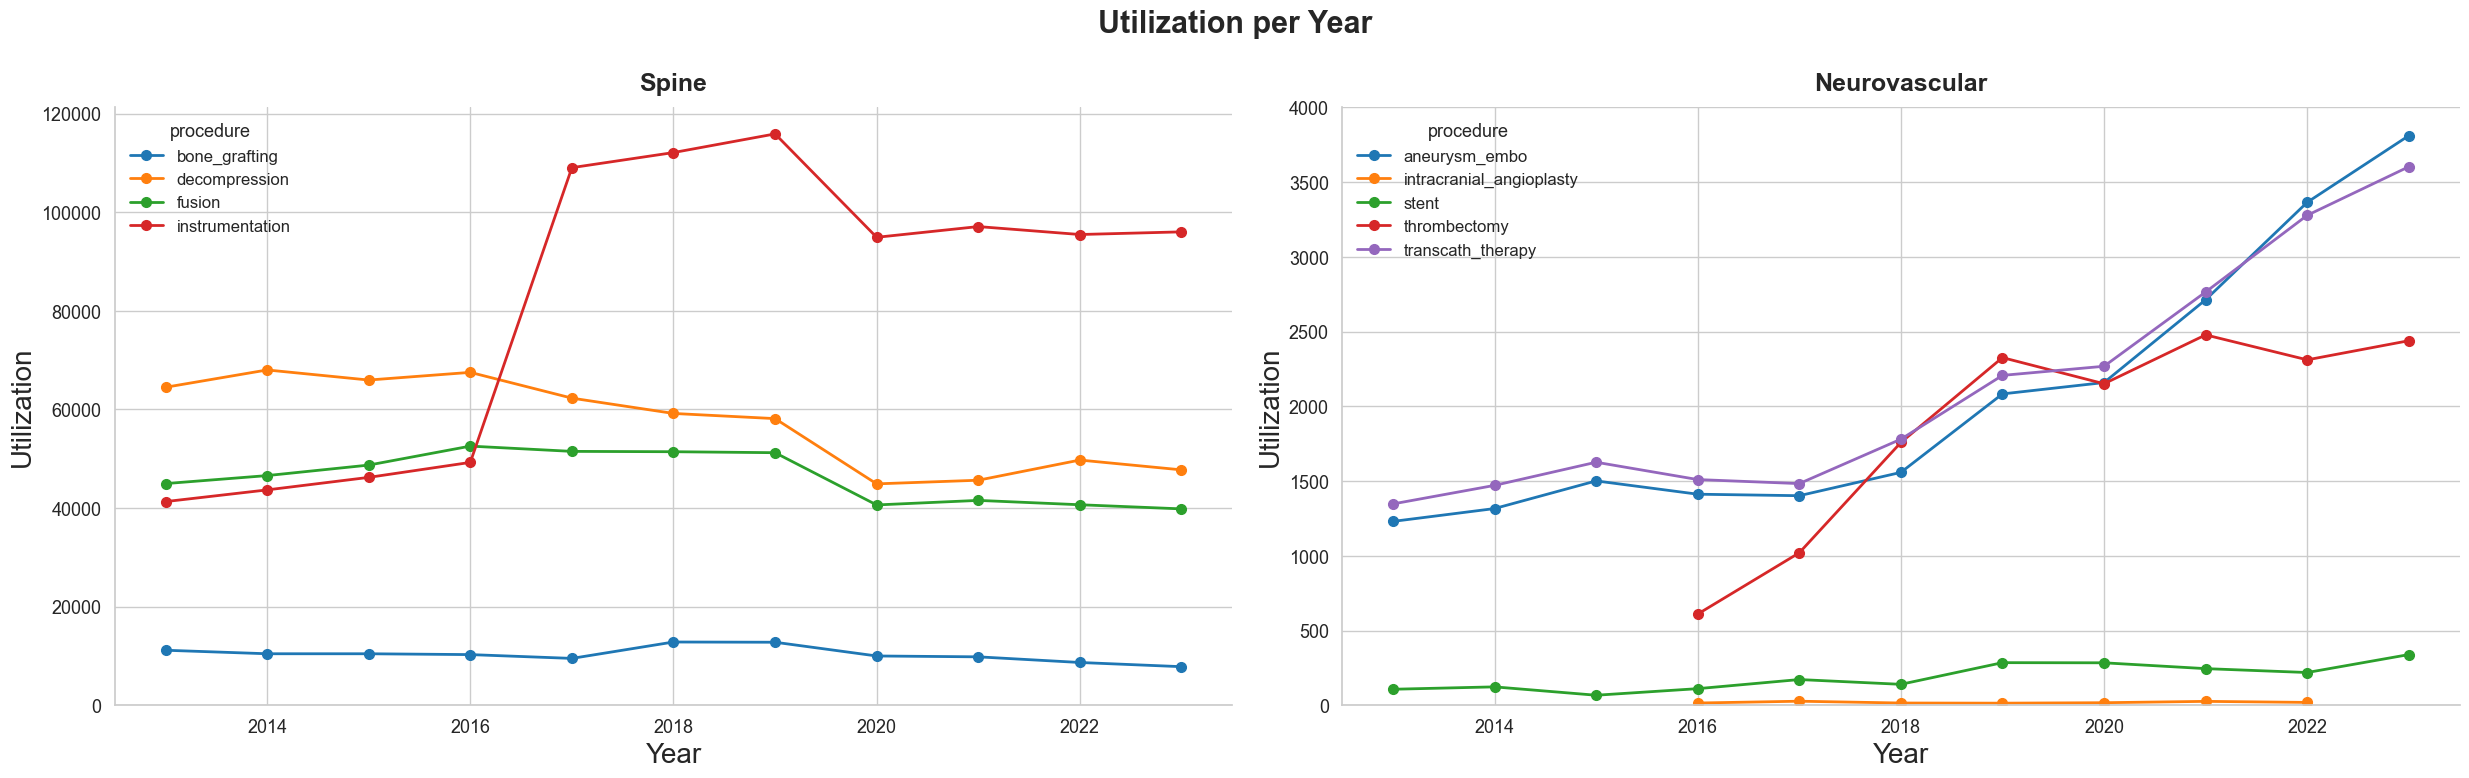

In [31]:
plot_by_specialty(
    [util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc],
    specialty_name,
    y_col='Sum_Utilization',
    y_label='Utilization',
    figsize=(25, 8),
    title="Utilization per Year"
)

# Average Standardized Payment

In [32]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Avg_Price_per_service_adj',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [33]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Spine | unweighted AAGR: -4.098 | weighted AAGR: -3.725

    procedure          AAGR_%
--  ---------------  --------
 0  bone_grafting    -4.2677
 1  decompression    -3.98315
 2  fusion           -2.89291
 3  instrumentation  -5.24987

Neurovascular | unweighted AAGR: -2.848 | weighted AAGR: -3.047

    procedure                   AAGR_%
--  ------------------------  --------
 0  aneurysm_embo             -3.03336
 1  intracranial_angioplasty  -2.82276
 2  stent                     -3.76425
 3  thrombectomy              -2.67942
 4  transcath_therapy         -1.94072



In [34]:
stats.ttest_ind(aagrs['Spine'][0]['AAGR_%'], aagrs['Neurovascular'][0]['AAGR_%'])

Ttest_indResult(statistic=-2.312547219105315, pvalue=0.053983840210454645)

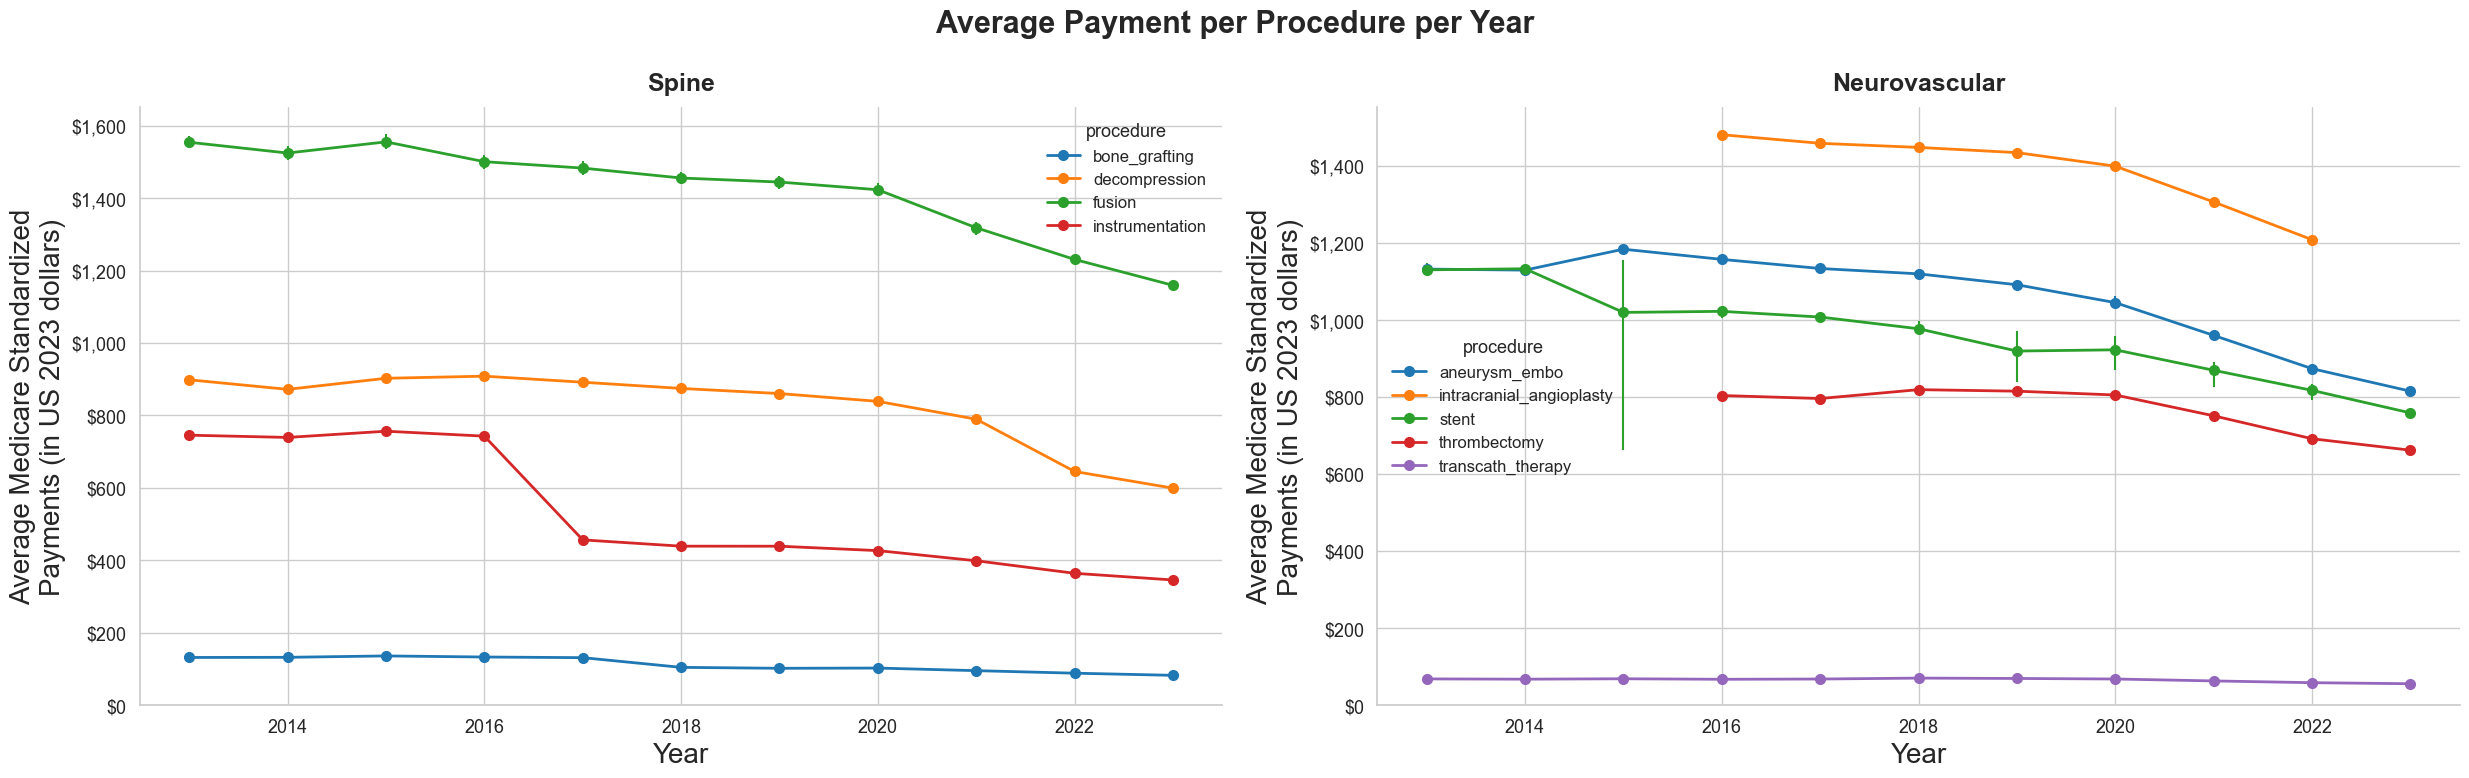

In [35]:
# Usage
plot_by_specialty_with_ci(
    [util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc],
    specialty_name,
    y_col='Agg_Price_per_service_adj',
    ci_lower_col='CI_lower_agg_price_adj',
    ci_upper_col='CI_upper_agg_price_adj',
    y_label="Average Medicare Standardized\nPayments (in US 2023 dollars)",
    title_prefix="Average Medicare Standardized Payment by Procedure Type",
    title="Average Payment per Procedure per Year"
)

# Total Payment

In [36]:
util_2023_2013_adj_spine['Sum_Pymt_adj'].sum(), util_2023_2013_adj_neurovasc['Sum_Pymt_adj'].sum()

(1662617872.321856, 38705752.00757038)

In [37]:
spine_total_payment_2013 = util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'] == 2013]['Sum_Pymt_adj'].sum()
spine_total_payment_2023 = util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'] == 2023]['Sum_Pymt_adj'].sum()

(spine_total_payment_2023 - spine_total_payment_2013) / spine_total_payment_2013 * 100

-29.50446785416495

In [152]:
neurovasc_total_payment_2013 = util_2023_2013_adj_neurovasc[util_2023_2013_adj_neurovasc['year'] == 2013]['Sum_Pymt_adj'].sum()
neurovasc_total_payment_2023 = util_2023_2013_adj_neurovasc[util_2023_2013_adj_neurovasc['year'] == 2023]['Sum_Pymt_adj'].sum()

(neurovasc_total_payment_2023 - neurovasc_total_payment_2013) / neurovasc_total_payment_2013 * 100

251.4765205037696

In [153]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Sum_Pymt_adj',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [154]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Spine | unweighted AAGR: -3.634 | weighted AAGR: -2.874

    procedure          AAGR_%
--  ---------------  --------
 0  bone_grafting    -7.09832
 1  decompression    -6.25081
 2  fusion           -3.22924
 3  instrumentation   2.04069

Neurovascular | unweighted AAGR: 13.937 | weighted AAGR: 15.51

    procedure                   AAGR_%
--  ------------------------  --------
 0  aneurysm_embo             10.0653
 1  intracranial_angioplasty   8.40044
 2  stent                     18.1665
 3  thrombectomy              23.9972
 4  transcath_therapy          9.05718



In [155]:
stats.ttest_ind(aagrs['Spine'][0]['AAGR_%'], aagrs['Neurovascular'][0]['AAGR_%'])

Ttest_indResult(statistic=-4.4757053203639074, pvalue=0.0028811076485469296)

In [156]:
cagrs = {}
for i, df in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    cagrs[specialty_name[i]] = compute_cagr(
        df,
        col='Sum_Pymt_adj',
        groupby_key='procedure',
        years=[2013, 2023]
    )

In [157]:
for specialty, cagr in cagrs.items():
    print(specialty)
    print(tabulate.tabulate(cagr, headers=cagr.columns))
    print()

Spine
    procedure          CAGR_pct    effective_start_year    effective_end_year
--  ---------------  ----------  ----------------------  --------------------
 0  bone_grafting      -7.52743                    2013                  2023
 1  decompression      -6.59853                    2013                  2023
 2  fusion             -3.55797                    2013                  2023
 3  instrumentation     1.14286                    2013                  2023

Neurovascular
    procedure                   CAGR_pct    effective_start_year    effective_end_year
--  ------------------------  ----------  ----------------------  --------------------
 0  aneurysm_embo                9.48939                    2013                  2023
 1  intracranial_angioplasty     1.10088                    2016                  2022
 2  stent                        9.26556                    2013                  2023
 3  thrombectomy                19.4869                     2016            

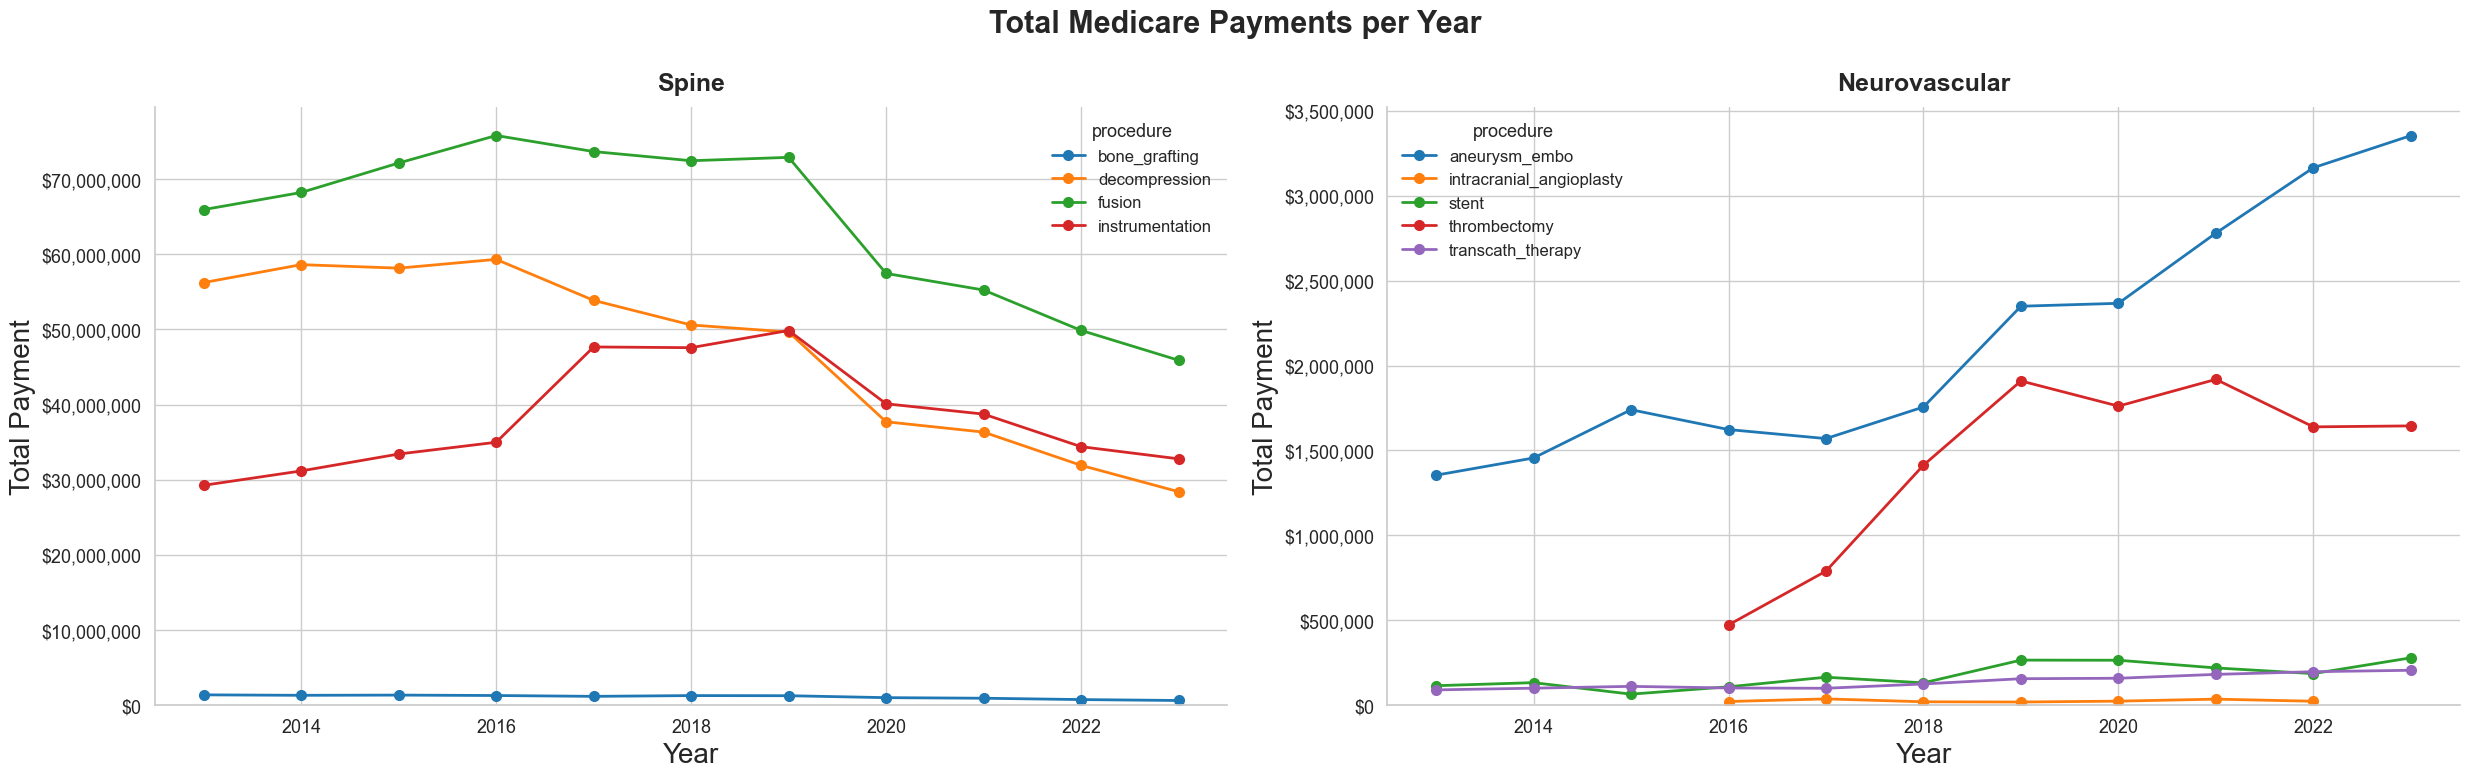

In [159]:
plot_by_specialty(
    [util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc],
    specialty_name,
    y_col='Sum_Pymt_adj',
    y_label='Total Payment',
    figsize=(25, 8),
    format_as_dollar=True,
    title="Total Medicare Payments per Year"
)

# Total Payment Growth Rate

In [219]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Sum_Pymt_adj',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [220]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Spine | unweighted AAGR: -3.634 | weighted AAGR: -2.874

    procedure          AAGR_%
--  ---------------  --------
 0  bone_grafting    -7.09832
 1  decompression    -6.25081
 2  fusion           -3.22924
 3  instrumentation   2.04069

Neurovascular | unweighted AAGR: 13.937 | weighted AAGR: 15.51

    procedure                   AAGR_%
--  ------------------------  --------
 0  aneurysm_embo             10.0653
 1  intracranial_angioplasty   8.40044
 2  stent                     18.1665
 3  thrombectomy              23.9972
 4  transcath_therapy          9.05718



In [221]:
stats.ttest_ind(aagrs['Spine'][0]['AAGR_%'], aagrs['Neurovascular'][0]['AAGR_%'])

Ttest_indResult(statistic=-4.4757053203639074, pvalue=0.0028811076485469296)

# Linear Regression by Change $ in Total Payment

In [102]:
# Usage
aagr_df_spine, aagr_df_neurovasc = compute_annual_change(
    [util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc],
    specialty_name,
    col='Sum_Pymt_adj',
    change_col_name='sum_pymt_change',
    start_year=2016,
    end_year=2023
)

In [103]:
x_variables = ['Sum_Utilization', 'Avg_Price_per_service_adj']

In [104]:
spine_data_for_regression = aagr_df_spine[['procedure', 'year', 'sum_pymt_change'] + x_variables]
spine_data_for_regression['specialty'] = 0

neurovasc_data_for_regression = aagr_df_neurovasc[['procedure', 'year', 'sum_pymt_change'] + x_variables]
neurovasc_data_for_regression['specialty'] = 1

all_regression_data = pd.concat([spine_data_for_regression, neurovasc_data_for_regression]).reset_index(drop=True).fillna(0)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_90746/793145289.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spine_data_for_regression['specialty'] = 0
/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_90746/793145289.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurovasc_data_for_regression['specialty'] = 1


In [105]:
X = all_regression_data.drop(columns=['sum_pymt_change', 'procedure']).dropna(subset=x_variables).fillna(False)
X = sm.add_constant(X)
y = all_regression_data['sum_pymt_change']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        sum_pymt_change   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     4.328
Date:                Sat, 09 May 2026   Prob (F-statistic):            0.00360
Time:                        11:34:35   Log-Likelihood:                -1156.9
No. Observations:                  71   AIC:                             2324.
Df Residuals:                      66   BIC:                             2335.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [101]:
-3.182e+05

-318200.0

# Linear Regression by Change Sum Utilization

In [71]:
# Usage
aagr_df_spine, aagr_df_neurovasc = compute_annual_change(
    [util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc],
    specialty_name,
    col='Sum_Utilization',
    change_col_name='sum_util_change',
    start_year=2013,
    end_year=2023
)

In [72]:
x_variables = ['Avg_Price_per_service_adj']

In [73]:
spine_data_for_regression = aagr_df_spine[['procedure', 'year', 'sum_util_change'] + x_variables]
spine_data_for_regression['specialty'] = 0

neurovasc_data_for_regression = aagr_df_neurovasc[['procedure', 'year', 'sum_util_change'] + x_variables]
neurovasc_data_for_regression['specialty'] = 1

all_regression_data = pd.concat([spine_data_for_regression, neurovasc_data_for_regression]).reset_index(drop=True).fillna(0)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_90746/1916421907.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spine_data_for_regression['specialty'] = 0
/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_90746/1916421907.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurovasc_data_for_regression['specialty'] = 1


In [74]:
X = all_regression_data.drop(columns=['sum_util_change', 'procedure']).dropna(subset=x_variables).fillna(False)
X = sm.add_constant(X)
y = all_regression_data['sum_util_change']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        sum_util_change   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                 -0.020
Method:                 Least Squares   F-statistic:                    0.4097
Date:                Sat, 09 May 2026   Prob (F-statistic):              0.746
Time:                        10:11:27   Log-Likelihood:                -944.04
No. Observations:                  92   AIC:                             1896.
Df Residuals:                      88   BIC:                             1906.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 